# EDA 03 — Train Moments

**Data source**: `train-moments` Azure Blob Storage container  
**Loaded by**: `src/data_loader.load_train_moment_files()` + `parse_train_moments()`  
**Output**: `data/processed/train_moments_clean.parquet`

This notebook explores the raw train movement records before any spatial join with road closures. Train moments capture real-time observations of trains at locations: arrivals, departures, and passing events with both planned and actual timestamps. Understanding this source independently reveals the baseline operational characteristics of rail services, data quality, and the natural delay distribution before any road-closure conditioning.

---
**Sections**
1. Load and inspect raw data  
2. Missing value audit  
3. Event type and variation status distributions  
4. Raw delay (timetable_variation) distribution  
5. Temporal distribution of movements  
6. Station code coverage (STANOX match rate)  
7. Operational flags (is_delayed, delay_monitoring_point, train_terminated)  
8. Platform, route and direction distributions  
9. Save cleaned output  


## 0. Setup

In [51]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)
os.makedirs("figures/eda_02", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load and Inspect Raw Data

In [52]:
from datetime import datetime, timezone
from src.data_loader import load_train_moment_files, parse_train_moments

START = datetime(2026, 4, 10, 0, 0, 0, tzinfo=timezone.utc)
END   = datetime(2026, 4, 12, 23, 59, 59, tzinfo=timezone.utc)

# Load stations_reference.parquet for station code mapping
stations_reference_df = pd.read_parquet(
    "./data/processed/stations_reference.parquet",
    engine="pyarrow"
)

train_files = load_train_moment_files(START, END)
print(f"Files retrieved: {len(train_files)}")

raw_df = parse_train_moments(train_files, stations_reference_df)
print(f"Raw shape: {raw_df.shape}")
print(f"Columns: {list(raw_df.columns)}")

Using 360 local files within the time window.
Files retrieved: 360
Raw shape: (41026, 32)
Columns: ['train_id', 'actual_timestamp', 'planned_timestamp', 'gbtt_timestamp', 'loc_stanox', 'next_stanox', 'event_type', 'planned_event_type', 'variation_status', 'timetable_variation', 'platform', 'route', 'direction', 'train_terminated', 'delay_monitoring_point', 'msg_timestamp', 'data_source', 'is_delayed', 'situation_id', 'record_id', 'start_time', 'end_time', 'validity_status', 'cause_type', 'source', 'road_name', 'lanes_closed', 'closure_lat', 'closure_lon', 'poslist', 'ingestion_time', 'station_code']


In [53]:
# Drop road-closure columns that leaked into train-moment blobs
drop_cols = [
    "situation_id", "record_id", "start_time", "end_time",
    "validity_status", "cause_type", "source", "road_name",
    "lanes_closed", "closure_lat", "closure_lon", "poslist", "ingestion_time",
]
raw_df = raw_df.drop(
    columns=[c for c in drop_cols if c in raw_df.columns]
)
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41026 entries, 0 to 41025
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   train_id                40949 non-null  object        
 1   actual_timestamp        39091 non-null  datetime64[ns]
 2   planned_timestamp       38649 non-null  datetime64[ns]
 3   gbtt_timestamp          26064 non-null  datetime64[ns]
 4   loc_stanox              39269 non-null  float64       
 5   next_stanox             37024 non-null  float64       
 6   event_type              39091 non-null  object        
 7   planned_event_type      39091 non-null  object        
 8   variation_status        39091 non-null  object        
 9   timetable_variation     39091 non-null  float64       
 10  platform                25057 non-null  object        
 11  route                   36782 non-null  object        
 12  direction               33430 non-null  object

In [54]:
raw_df.head()

,train_id,actual_timestamp,planned_timestamp,gbtt_timestamp,loc_stanox,next_stanox,event_type,planned_event_type,variation_status,timetable_variation,platform,route,direction,train_terminated,delay_monitoring_point,msg_timestamp,data_source,is_delayed,station_code
0,015H562C10,2026-04-10 08:15:00,2026-04-10 08:20:30,2026-04-10 08:20:00,1008.0,NaN,DEPARTURE,DEPARTURE,EARLY,5.0,NaN,NaN,NaN,True,True,1.775811e+12,SDR,0.0,GGJ
1,512O17MF10,2026-04-10 09:47:00,2026-04-10 09:47:30,2026-04-10 09:48:00,51717.0,51720.0,ARRIVAL,ARRIVAL,ON TIME,0.0,1,0.0,UP,False,False,1.775811e+12,SMART,0.0,RYH
2,522S14ME10,2026-04-10 09:46:00,2026-04-10 09:46:00,NaT,51914.0,51913.0,DEPARTURE,DEPARTURE,ON TIME,0.0,2,1.0,DOWN,False,True,1.775811e+12,SMART,0.0,BMD
3,525E20MF10,2026-04-10 09:47:00,NaT,NaT,52705.0,NaN,ARRIVAL,ARRIVAL,OFF ROUTE,0.0,NaN,NaN,NaN,False,False,1.775811e+12,SMART,0.0,LHS
4,522T37MF10,2026-04-10 09:47:00,2026-04-10 09:46:30,2026-04-10 09:47:00,52729.0,52733.0,ARRIVAL,ARRIVAL,LATE,1.0,1,0.0,UP,False,False,1.775811e+12,SMART,1.0,WST


In [55]:
raw_df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
train_id,40949,18976,841S51MK10,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
actual_timestamp,39091,NaN,NaN,NaN,2026-04-11 07:44:24.536594176,2026-04-03 23:44:00,2026-04-10 13:52:00,2026-04-10 21:41:00,2026-04-12 16:40:00,2026-04-12 23:26:00,NaN
planned_timestamp,38649,NaN,NaN,NaN,2026-04-11 07:43:13.653651968,2026-04-03 23:56:00,2026-04-10 13:50:00,2026-04-10 21:39:30,2026-04-12 16:39:30,2026-04-12 23:57:00,NaN
gbtt_timestamp,26064,NaN,NaN,NaN,2026-04-11 07:45:17.799263488,2026-04-03 23:56:00,2026-04-10 13:51:00,2026-04-10 21:36:00,2026-04-12 16:42:15,2026-04-12 23:31:00,NaN
loc_stanox,39269.0,NaN,NaN,NaN,57244.216303,850.0,36078.0,63629.0,86218.0,89743.0,27808.632834
next_stanox,37024.0,NaN,NaN,NaN,57179.530359,750.0,36070.0,63621.0,86248.0,89743.0,27831.72612
event_type,39091,2,DEPARTURE,23552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
planned_event_type,39091,3,DEPARTURE,23552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
variation_status,39091,4,LATE,15638,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timetable_variation,39091.0,NaN,NaN,NaN,2.533627,0.0,0.0,1.0,2.0,293.0,7.20561


## 2. Missing Value Audit

The two most critical fields for the main analysis are `actual_timestamp` and `planned_timestamp`. Missing values in these fields prevent delay computation and cause rows to be dropped by the filtering pipeline.

In [56]:
missing = pd.DataFrame({
    "missing_count": raw_df.isna().sum(),
    "missing_pct": (raw_df.isna().sum() / len(raw_df) * 100).round(2)
}).sort_values("missing_pct", ascending=False)

print(missing.to_string())

                        missing_count  missing_pct
platform                        15969        38.92
gbtt_timestamp                  14962        36.47
station_code                    11248        27.42
direction                        7596        18.52
route                            4244        10.34
next_stanox                      4002         9.75
planned_timestamp                2377         5.79
delay_monitoring_point           1935         4.72
actual_timestamp                 1935         4.72
variation_status                 1935         4.72
event_type                       1935         4.72
planned_event_type               1935         4.72
timetable_variation              1935         4.72
train_terminated                 1935         4.72
loc_stanox                       1757         4.28
data_source                       156         0.38
train_id                           77         0.19
msg_timestamp                      77         0.19
is_delayed                     

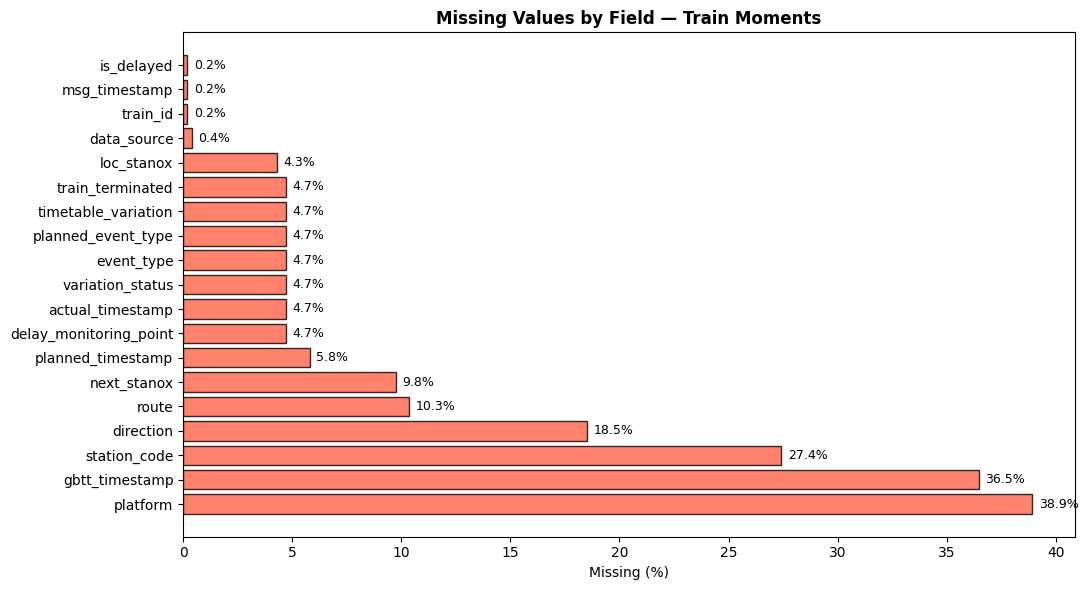

In [57]:
fig, ax = plt.subplots(figsize=(11, 6))
missing_nonzero = missing[missing["missing_pct"] > 0]
if len(missing_nonzero) > 0:
    ax.barh(missing_nonzero.index, missing_nonzero["missing_pct"],
            color="tomato", edgecolor="black", alpha=0.8)
    ax.set_xlabel("Missing (%)")
    ax.set_title("Missing Values by Field — Train Moments", fontweight="bold")
    for i, v in enumerate(missing_nonzero["missing_pct"]):
        ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
else:
    ax.text(0.5, 0.5, "No missing values", ha="center", va="center",
            transform=ax.transAxes, fontsize=14)
plt.tight_layout()
plt.savefig("figures/eda_02/missing_values.png", dpi=200, bbox_inches="tight")
plt.show()

In [58]:
# Critical field missingness breakdown
print("actual_timestamp missing:  ", raw_df["actual_timestamp"].isna().sum(),
      f"({raw_df['actual_timestamp'].isna().mean()*100:.1f}%)")
print("planned_timestamp missing: ", raw_df["planned_timestamp"].isna().sum(),
      f"({raw_df['planned_timestamp'].isna().mean()*100:.1f}%)")
print("Both missing:              ",
      (raw_df["actual_timestamp"].isna() & raw_df["planned_timestamp"].isna()).sum())
print("Either missing:            ",
      (raw_df["actual_timestamp"].isna() | raw_df["planned_timestamp"].isna()).sum())

actual_timestamp missing:   1935 (4.7%)
planned_timestamp missing:  2377 (5.8%)
Both missing:               1935
Either missing:             2377


## 3. Event Type and Variation Status

In [59]:
print("=== Event Type ===")
et = raw_df["event_type"].value_counts()
print(et.to_string())
print()

print("=== Planned Event Type ===")
if "planned_event_type" in raw_df.columns:
    pet = raw_df["planned_event_type"].value_counts()
    print(pet.to_string())

=== Event Type ===
event_type
DEPARTURE    23552
ARRIVAL      15539

=== Planned Event Type ===
planned_event_type
DEPARTURE      23552
ARRIVAL        14066
DESTINATION     1473


In [60]:
print("=== Variation Status ===")
vs = raw_df["variation_status"].value_counts()
print(vs.to_string())

=== Variation Status ===
variation_status
LATE         15638
ON TIME      13180
EARLY         9831
OFF ROUTE      442


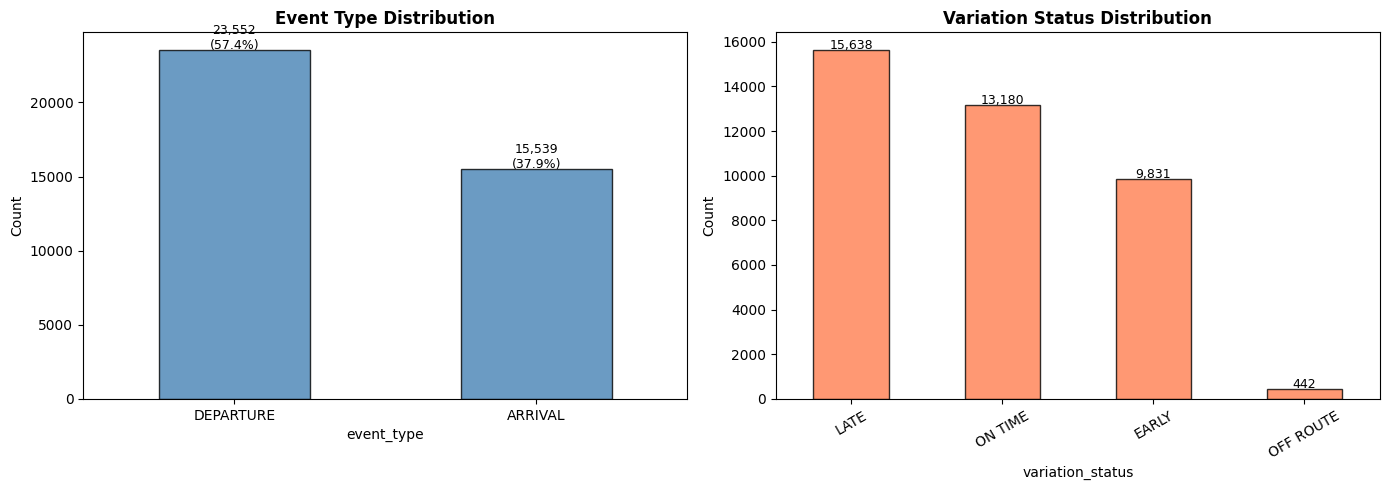

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

et.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Event Type Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(et.values):
    axes[0].text(i, v + 50, f"{v:,}\n({v/len(raw_df)*100:.1f}%)",
                 ha="center", fontsize=9)

vs.plot(kind="bar", ax=axes[1], color="coral", edgecolor="black", alpha=0.8)
axes[1].set_title("Variation Status Distribution", fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)
for i, v in enumerate(vs.values):
    axes[1].text(i, v + 50, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("figures/eda_02/event_variation.png", dpi=200, bbox_inches="tight")
plt.show()

In [62]:
# Cross tab: event type vs variation status
if "variation_status" in raw_df.columns:
    ct = pd.crosstab(raw_df["event_type"], raw_df["variation_status"], margins=True)
    print(ct.to_string())

variation_status  EARLY   LATE  OFF ROUTE  ON TIME    All
event_type                                               
ARRIVAL            3855   6368        181     5135  15539
DEPARTURE          5976   9270        261     8045  23552
All                9831  15638        442    13180  39091


## 4. Raw Delay Distribution (timetable_variation)

`timetable_variation` is the raw delay in minutes as reported in the train moments feed — this is the delay BEFORE any road-closure conditioning. It represents the natural delay distribution of UK rail services across the observation period.

In [63]:
if "timetable_variation" in raw_df.columns:
    tv = raw_df["timetable_variation"].dropna()
    print("timetable_variation statistics:")
    print(tv.describe().round(2))
    print(f"\nSkewness: {tv.skew():.3f}")
    print(f"Kurtosis: {tv.kurtosis():.3f}")
    print(f"\nQuantiles:")
    print(tv.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2))

timetable_variation statistics:
count    39091.00
mean         2.53
std          7.21
min          0.00
25%          0.00
50%          1.00
75%          2.00
max        293.00
Name: timetable_variation, dtype: float64

Skewness: 12.308
Kurtosis: 255.696

Quantiles:
0.01     0.0
0.05     0.0
0.25     0.0
0.50     1.0
0.75     2.0
0.95    10.0
0.99    28.0
Name: timetable_variation, dtype: float64


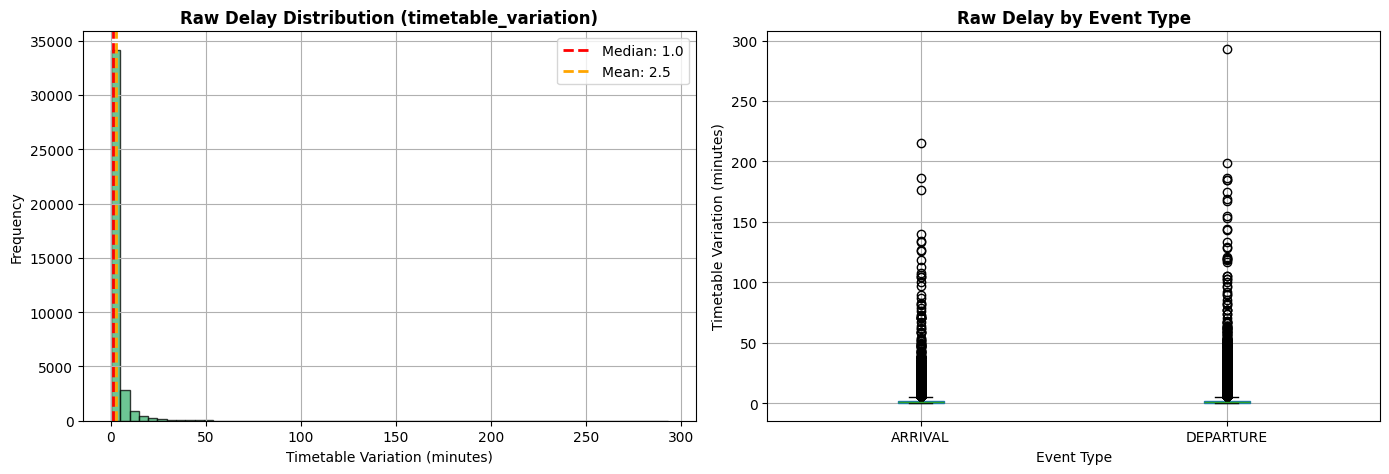

In [64]:
if "timetable_variation" in raw_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    tv = raw_df["timetable_variation"].dropna()

    tv.hist(bins=60, ax=axes[0], edgecolor="black", alpha=0.75, color="mediumseagreen")
    axes[0].axvline(tv.median(), color="red", linestyle="--", lw=2,
                    label=f"Median: {tv.median():.1f}")
    axes[0].axvline(tv.mean(), color="orange", linestyle="--", lw=2,
                    label=f"Mean: {tv.mean():.1f}")
    axes[0].set_xlabel("Timetable Variation (minutes)")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title("Raw Delay Distribution (timetable_variation)", fontweight="bold")
    axes[0].legend()

    raw_df.boxplot(column="timetable_variation", by="event_type", ax=axes[1],
                   patch_artist=True)
    axes[1].set_title("Raw Delay by Event Type", fontweight="bold")
    axes[1].set_xlabel("Event Type")
    axes[1].set_ylabel("Timetable Variation (minutes)")
    plt.suptitle("")

    plt.tight_layout()
    plt.savefig("figures/eda_02/raw_delay_distribution.png", dpi=200, bbox_inches="tight")
    plt.show()

## 5. Temporal Distribution of Movements

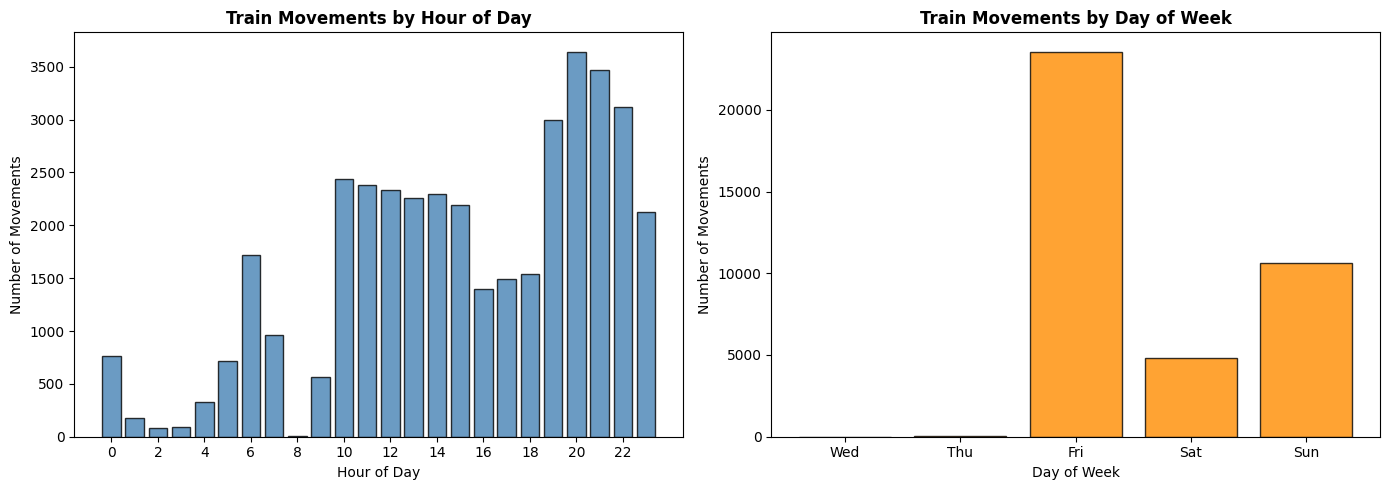

In [65]:
raw_df["actual_hour"] = raw_df["actual_timestamp"].dt.hour
raw_df["actual_dow"]  = raw_df["actual_timestamp"].dt.dayofweek
raw_df["actual_date"] = raw_df["actual_timestamp"].dt.date

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hour_counts = raw_df["actual_hour"].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values,
            color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Number of Movements")
axes[0].set_title("Train Movements by Hour of Day", fontweight="bold")
axes[0].set_xticks(range(0, 24, 2))

dow_map = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
dow_counts = raw_df["actual_dow"].value_counts().sort_index()
axes[1].bar([dow_map.get(i, str(i)) for i in dow_counts.index],
            dow_counts.values, color="darkorange", edgecolor="black", alpha=0.8)
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Number of Movements")
axes[1].set_title("Train Movements by Day of Week", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/eda_02/temporal_movements.png", dpi=200, bbox_inches="tight")
plt.show()

In [66]:
# Day-level summary
print("Movements by date:")
print(raw_df["actual_date"].value_counts().sort_index().to_string())

Movements by date:
actual_date
2026-04-03        1
2026-04-08        1
2026-04-09       65
2026-04-10    23562
2026-04-11     4804
2026-04-12    10658


## 6. Station Code Coverage (STANOX Match Rate)

In [67]:
if "station_code" in raw_df.columns:
    matched = raw_df["station_code"].notna() & (raw_df["station_code"] != "")
    total   = len(raw_df)
    print(f"Total movements:              {total:,}")
    print(f"With station code matched:    {matched.sum():,} ({matched.mean()*100:.1f}%)")
    print(f"Without station code:         {(~matched).sum():,} ({(~matched).mean()*100:.1f}%)")
    print()

    # Station code distribution (top 20)
    top_stations = raw_df[matched]["station_code"].value_counts().head(20)
    print("Top 20 station codes by movement count:")
    print(top_stations.to_string())

Total movements:              41,026
With station code matched:    29,778 (72.6%)
Without station code:         11,248 (27.4%)

Top 20 station codes by movement count:
station_code
CLJ    221
LBG    133
VXH    114
SRA    101
WIM    100
NXG     91
ECR     90
ZCW     89
NEM     88
EAL     88
SDC     87
FPK     86
WAE     85
BAL     84
ROE     83
DLJ     82
WAT     81
BET     81
STL     80
SDE     80


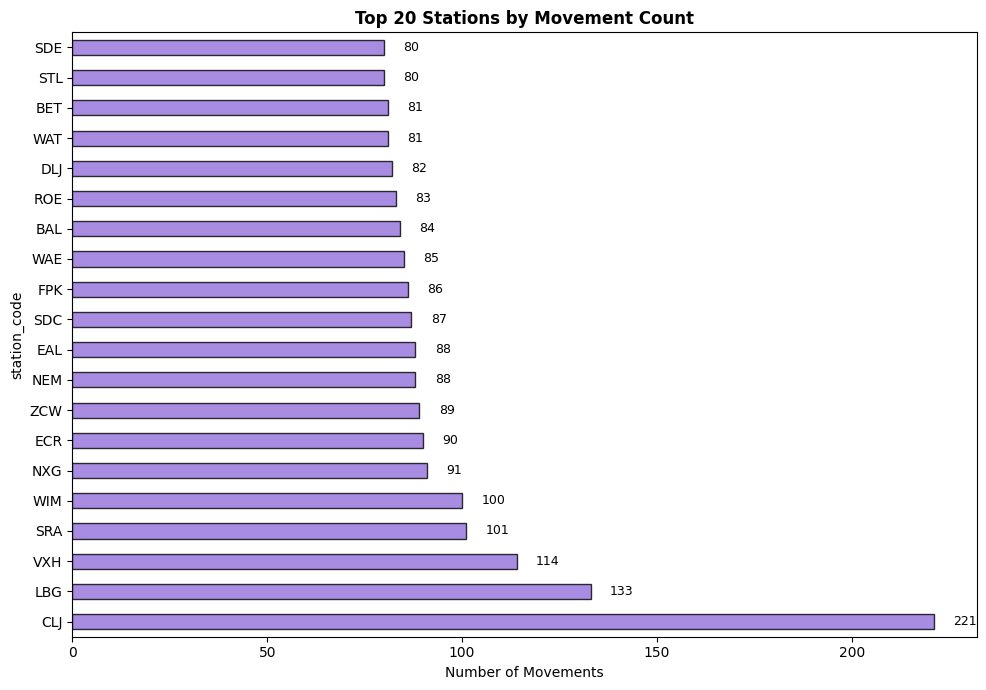

In [68]:
if "station_code" in raw_df.columns:
    matched = raw_df["station_code"].notna() & (raw_df["station_code"] != "")
    top_stations = raw_df[matched]["station_code"].value_counts().head(20)

    plt.figure(figsize=(10, 7))
    top_stations.plot(kind="barh", color="mediumpurple", edgecolor="black", alpha=0.8)
    plt.xlabel("Number of Movements")
    plt.title("Top 20 Stations by Movement Count", fontweight="bold")
    for i, v in enumerate(top_stations.values):
        plt.text(v + 5, i, str(v), va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("figures/eda_02/top_stations_movements.png", dpi=200, bbox_inches="tight")
    plt.show()

## 7. Operational Flags

In [69]:
flag_cols = ["is_delayed", "delay_monitoring_point", "train_terminated"]
for col in flag_cols:
    if col in raw_df.columns:
        vc = raw_df[col].value_counts(dropna=False)
        pct_true = raw_df[col].eq(True).sum() / len(raw_df) * 100
        print(f"=== {col} ===")
        print(vc.to_string())
        print(f"  True rate: {pct_true:.1f}%")
        print()

=== is_delayed ===
is_delayed
0.0    25311
1.0    15638
NaN       77
  True rate: 38.1%

=== delay_monitoring_point ===
delay_monitoring_point
False    20251
True     18840
NaN       1935
  True rate: 45.9%

=== train_terminated ===
train_terminated
False    37466
NaN       1935
True      1625
  True rate: 4.0%



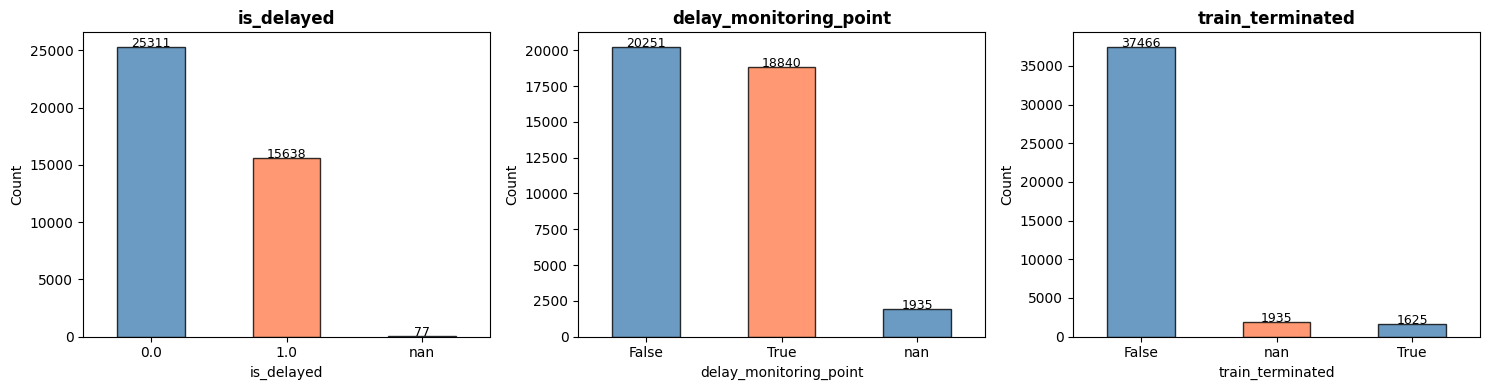

In [70]:
flag_cols_present = [c for c in ["is_delayed", "delay_monitoring_point", "train_terminated"]
                    if c in raw_df.columns]

if flag_cols_present:
    fig, axes = plt.subplots(1, len(flag_cols_present), figsize=(5*len(flag_cols_present), 4))
    if len(flag_cols_present) == 1:
        axes = [axes]

    for ax, col in zip(axes, flag_cols_present):
        vc = raw_df[col].value_counts(dropna=False)
        vc.plot(kind="bar", ax=ax, color=["steelblue", "coral"], edgecolor="black", alpha=0.8)
        ax.set_title(col, fontweight="bold")
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=0)
        for i, v in enumerate(vc.values):
            ax.text(i, v + 5, str(v), ha="center", fontsize=9)

    plt.tight_layout()
    plt.savefig("figures/eda_02/operational_flags.png", dpi=200, bbox_inches="tight")
    plt.show()

## 8. Platform, Route and Direction Distributions

In [71]:
for col in ["platform", "route", "direction", "data_source"]:
    if col in raw_df.columns:
        vc = raw_df[col].value_counts(dropna=False).head(15)
        print(f"=== {col} ===")
        print(vc.to_string())
        print()

=== platform ===
platform
NaN    15969
1       6113
2       5937
1.0     3182
2.0     3148
3       1549
4       1159
3.0      833
4.0      557
5        411
6        222
5.0      214
8        167
7        161
6.0      139

=== route ===
route
0.0    15060
1.0     9899
2.0     9057
NaN     4244
3.0     1497
4.0      414
0        289
1        197
2        147
6.0       61
5.0       53
7.0       39
3         26
8.0       14
4          9

=== direction ===
direction
DOWN    16726
UP      16704
NaN      7596

=== data_source ===
data_source
SMART        36274
TSIA          1680
GPS           1610
SDR           1165
NaN            156
TRUST DA        85
TOPS            50
TM ROC 30        6



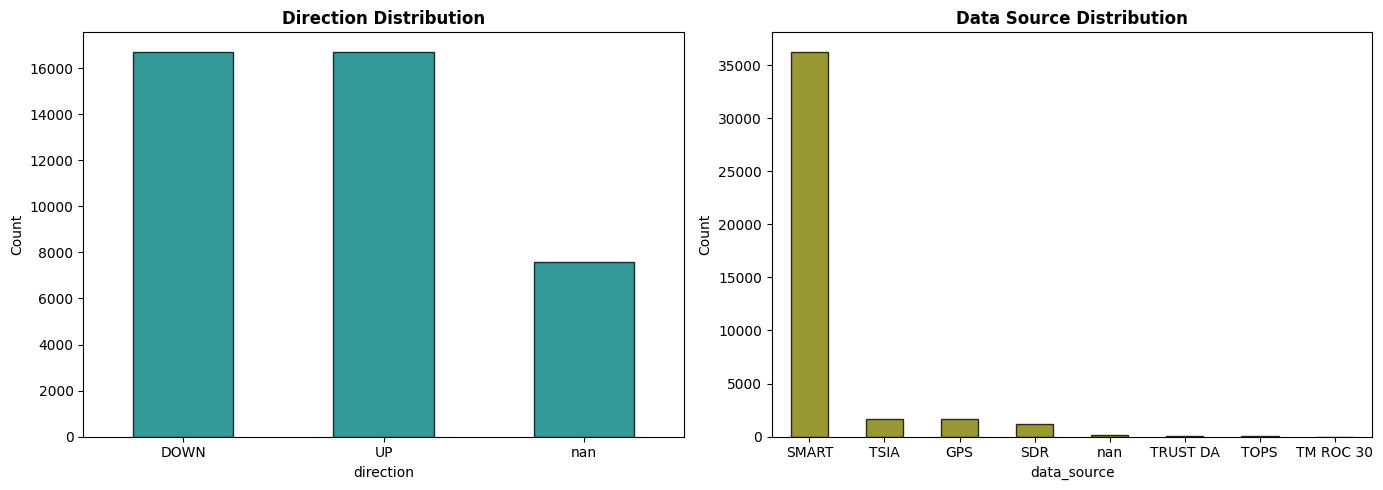

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if "direction" in raw_df.columns:
    dir_counts = raw_df["direction"].value_counts(dropna=False)
    dir_counts.plot(kind="bar", ax=axes[0], color="teal", edgecolor="black", alpha=0.8)
    axes[0].set_title("Direction Distribution", fontweight="bold")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=0)

if "data_source" in raw_df.columns:
    ds_counts = raw_df["data_source"].value_counts(dropna=False)
    ds_counts.plot(kind="bar", ax=axes[1], color="olive", edgecolor="black", alpha=0.8)
    axes[1].set_title("Data Source Distribution", fontweight="bold")
    axes[1].set_ylabel("Count")
    axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("figures/eda_02/platform_direction.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Summary and Cleaned Output

Key findings:
- **41,026 raw rows** retrieved; after dropping rows where both timestamps are null: **39,091 rows**
- `actual_timestamp` and `planned_timestamp` are the critical fields — missing rate documented above
- `timetable_variation` represents the raw operational delay before road-closure conditioning
- Station code match rate reflects STANOX → 3ALPHA lookup coverage
- Night-hour movements are present but sparse; peak hours are morning and evening commute periods


In [73]:
# Drop rows where both timestamps are missing
before = len(raw_df)
clean_df = raw_df.dropna(subset=["actual_timestamp", "planned_timestamp"], how="all")
print(f"Dropped {before - len(clean_df):,} rows (both timestamps null)")
print(f"Final train moments dataset: {len(clean_df):,} rows")


clean_df["platform"] = clean_df["platform"].astype("string")
clean_df["route"] = clean_df["route"].astype("string")

clean_df.to_parquet("./data/processed/train_moments_clean.parquet", index=False)
print("Saved to data/processed/train_moments_clean.parquet")

Dropped 1,935 rows (both timestamps null)
Final train moments dataset: 39,091 rows


C:\Users\home\AppData\Local\Temp\ipykernel_23660\820547098.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["platform"] = clean_df["platform"].astype("string")
C:\Users\home\AppData\Local\Temp\ipykernel_23660\820547098.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["route"] = clean_df["route"].astype("string")


Saved to data/processed/train_moments_clean.parquet
